# Train LogReg v5 & Compare vs v4

Notebook port of `scripts/train_and_compare_v5.py`.

Trains a compact microstructure LogReg (v5) and benchmarks it against the existing v4 model on the same walk-forward held-out slots, then runs a $100 Kelly backtest on both and plots equity curves inline.

**v5 features:** `ret_30s, ret_60s, depth_ratio, depth_skew, imbalance, spread, wall_flag, depth_change, mid_return_5s, acceleration, rolling_std_30s, range_30s, time_to_expiry`

## 1. Imports & paths

In [1]:
from __future__ import annotations

import json
import math
import os
import pickle
import sys

import numpy as np
import pandas as pd

# Resolve repo root from notebook cwd (notebooks/ sits under repo root)
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
SCRIPTS_DIR = os.path.join(REPO_ROOT, "scripts")
for p in (REPO_ROOT, SCRIPTS_DIR):
    if p not in sys.path:
        sys.path.insert(0, p)

# Reuse label derivation + BTC feature helpers from the v3 training script
import train_logreg_v3 as v3

print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: c:\Users\seohj\Desktop\stuffs\side_projects\polymarket


## 2. Feature lists

In [2]:
V5_FEATURES = [
    "ret_30s", "ret_60s",
    "depth_ratio", "depth_skew", "imbalance", "spread",
    "wall_flag", "depth_change",
    "mid_return_5s", "acceleration",
    "rolling_std_30s", "range_30s",
    "time_to_expiry",
]

V4_FEATURES = [
    "time_to_expiry",
    "ret_5s", "ret_15s", "ret_30s", "ret_60s", "ret_180s",
    "vol_15s", "vol_30s", "vol_60s", "vol_ratio_15_60",
    "volume_surge_ratio", "vwap_deviation", "cvd_60s",
    "rsi_14", "td_setup_net",
    "spread", "ob_imbalance", "ob_cross_imbalance",
]

## 3. Dataset builder

Causal within each slot. Emits every column needed to train v5, score v4, and run the backtest.

In [3]:
def build_dataset(ob_df: pd.DataFrame, btc_df: pd.DataFrame,
                  labels: dict[int, int], row_interval: int = 15) -> pd.DataFrame:
    ts = btc_df["timestamp"].values.astype(float)
    close = btc_df["close"].values.astype(float)
    vol_arr = btc_df["volume"].values.astype(float)

    up_ob = ob_df[ob_df["side"] == "up"]
    dn_ob = ob_df[ob_df["side"] == "down"]

    rows = []
    for slot_ts, y in sorted(labels.items()):
        expiry = slot_ts + 300
        si = v3._asof(ts, float(slot_ts))
        if si < 0:
            continue

        slot_up = up_ob[up_ob["slot_ts"] == slot_ts].sort_values("elapsed_s").reset_index(drop=True)
        slot_dn = dn_ob[dn_ob["slot_ts"] == slot_ts].sort_values("elapsed_s").reset_index(drop=True)
        if slot_up.empty:
            continue

        up_e = slot_up["elapsed_s"].values.astype(float)
        up_mid_arr = slot_up["mid"].values.astype(float)
        up_bd = slot_up["bid_depth_3"].values.astype(float)
        up_ad = slot_up["ask_depth_3"].values.astype(float)
        dn_e = slot_dn["elapsed_s"].values.astype(float) if not slot_dn.empty else None
        dn_bd = slot_dn["bid_depth_3"].values.astype(float) if not slot_dn.empty else None

        elapsed_vals = sorted(slot_up["elapsed_s"].unique())
        sampled = [e for e in elapsed_vals
                   if e >= row_interval and e < 280 and e % row_interval < 3]
        if not sampled:
            continue

        for elapsed in sampled:
            t = float(slot_ts + elapsed)
            tte = expiry - t
            if v3._asof(ts, t) < 0:
                continue

            cur = int(np.abs(up_e - elapsed).argmin())
            up_row = slot_up.iloc[cur]
            up_bid_d = float(up_bd[cur])
            up_ask_d = float(up_ad[cur])
            up_mid_now = float(up_mid_arr[cur])
            up_best_bid = float(up_row.get("best_bid", 0) or 0.0)
            up_best_ask = float(up_row.get("best_ask", 0) or 0.0)
            spread = float(up_row["spread"])

            # depth features
            eps = 1.0
            depth_ratio = math.log((up_bid_d + eps) / (up_ask_d + eps))
            ob_total = up_bid_d + up_ask_d
            depth_skew = (up_bid_d - up_ask_d) / ob_total if ob_total > 0 else 0.0

            # cross-side imbalance
            imbalance = 0.5
            dn_best_ask = 0.0
            dn_best_bid = 0.0
            if dn_e is not None:
                dn_i = int(np.abs(dn_e - elapsed).argmin())
                dn_row = slot_dn.iloc[dn_i]
                dn_bid_d = float(dn_bd[dn_i])
                cross = up_bid_d + dn_bid_d
                imbalance = up_bid_d / cross if cross > 0 else 0.5
                dn_best_ask = float(dn_row.get("best_ask", 0) or 0.0)
                dn_best_bid = float(dn_row.get("best_bid", 0) or 0.0)

            # causal intra-slot history (up side)
            hist_mask = up_e <= elapsed
            he = up_e[hist_mask]
            hm = up_mid_arr[hist_mask]
            hbd = up_bd[hist_mask]
            had = up_ad[hist_mask]

            # wall_flag: current max side depth vs mean of all side depth so far
            all_d = np.concatenate([hbd, had]) if hbd.size else np.array([])
            mean_d = float(all_d.mean()) if all_d.size else 0.0
            max_now = max(up_bid_d, up_ask_d)
            wall_flag = 1.0 if mean_d > 0 and max_now > 2.0 * mean_d else 0.0

            # depth_change: Δ(bd+ad) over ~5s
            depth_change = 0.0
            mid_5s_ago = None
            past5 = he <= elapsed - 5
            if past5.any():
                j = int(np.nonzero(past5)[0][-1])
                depth_change = (up_bid_d + up_ask_d) - (hbd[j] + had[j])
                mid_5s_ago = float(hm[j])

            # mid_return_5s
            mid_return_5s = 0.0
            if mid_5s_ago and up_mid_now > 0:
                mid_return_5s = math.log(up_mid_now / mid_5s_ago)

            # acceleration: 5s-return diff (now vs 5s earlier)
            accel = 0.0
            past10 = he <= elapsed - 10
            if past10.any() and mid_5s_ago:
                k = int(np.nonzero(past10)[0][-1])
                mid_10s_ago = float(hm[k])
                if mid_10s_ago > 0 and mid_5s_ago > 0:
                    prev_ret = math.log(mid_5s_ago / mid_10s_ago)
                    accel = mid_return_5s - prev_ret

            # 30s rolling stats on up_mid
            win = he >= elapsed - 30
            wmid = hm[win]
            rolling_std_30s = float(np.std(wmid, ddof=1)) if wmid.size > 1 else 0.0
            range_30s = float(wmid.max() - wmid.min()) if wmid.size > 0 else 0.0

            # v4 BTC features (for scoring v4 on same rows)
            v15 = v3._vol(ts, close, t, 15)
            v30 = v3._vol(ts, close, t, 30)
            v60 = v3._vol(ts, close, t, 60)

            rows.append({
                "slot_ts": slot_ts, "elapsed": elapsed, "t": t, "y": y,
                "time_to_expiry": tte,
                "ret_5s": v3._ret(ts, close, t, 5),
                "ret_15s": v3._ret(ts, close, t, 15),
                "ret_30s": v3._ret(ts, close, t, 30),
                "ret_60s": v3._ret(ts, close, t, 60),
                "ret_180s": v3._ret(ts, close, t, 180),
                "vol_15s": v15, "vol_30s": v30, "vol_60s": v60,
                "vol_ratio_15_60": (v15 / v60) if v60 > 0 else 0.0,
                "volume_surge_ratio": v3._volume_features(ts, vol_arr, t),
                "vwap_deviation": v3._vwap_deviation(ts, close, vol_arr, t),
                "cvd_60s": v3._cvd(ts, close, vol_arr, t),
                "rsi_14": v3._rsi(ts, close, t),
                "td_setup_net": v3._td_setup_net(ts, close, t),
                "spread": spread,
                "ob_imbalance": depth_skew,
                "ob_cross_imbalance": imbalance,
                "depth_ratio": depth_ratio,
                "depth_skew": depth_skew,
                "imbalance": imbalance,
                "wall_flag": wall_flag,
                "depth_change": depth_change,
                "mid_return_5s": mid_return_5s,
                "acceleration": accel,
                "rolling_std_30s": rolling_std_30s,
                "range_30s": range_30s,
                "up_best_bid": up_best_bid,
                "up_best_ask": up_best_ask,
                "dn_best_bid": dn_best_bid,
                "dn_best_ask": dn_best_ask,
                "up_mid": up_mid_now,
            })
    return pd.DataFrame(rows).sort_values(["slot_ts", "t"]).reset_index(drop=True)

## 4. Scoring & backtest helpers

In [4]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def score_linear(X: np.ndarray, scaler, coef: np.ndarray, intercept: float) -> np.ndarray:
    """Direct sigmoid scoring — avoids sklearn pickle attribute drift."""
    Xs = scaler.transform(X)
    return sigmoid(Xs @ coef + intercept)


def kelly_frac(p: float, price: float) -> float:
    if price <= 0 or price >= 1:
        return 0.0
    f = (p - price) / (1.0 - price)
    return max(0.0, f)


def backtest(df_valid: pd.DataFrame, p_up: np.ndarray, *,
             starting_equity: float = 100.0,
             edge_threshold: float = 0.02,
             kelly_mult: float = 0.15,
             max_frac: float = 0.10) -> pd.DataFrame:
    """For each valid slot, take the first decision row where |edge| > threshold.
    Fill at the relevant side's best_ask. Resolve immediately on slot outcome."""
    df = df_valid.copy()
    df["p_up"] = p_up

    equity = starting_equity
    history = []
    for slot_ts, grp in df.groupby("slot_ts", sort=True):
        y = int(grp["y"].iloc[0])
        traded = False
        for _, row in grp.iterrows():
            p = float(row["p_up"])
            up_ask = float(row["up_best_ask"]) or float(row["up_mid"])
            dn_ask = float(row["dn_best_ask"])
            if dn_ask <= 0:
                dn_ask = max(0.01, 1.0 - float(row["up_mid"]))

            edge_up = p - up_ask
            edge_dn = (1.0 - p) - dn_ask
            if edge_up > edge_threshold and edge_up >= edge_dn:
                side, price, win = "up", up_ask, (y == 1)
            elif edge_dn > edge_threshold:
                side, price, win = "dn", dn_ask, (y == 0)
            else:
                continue

            if not (0.0 < price < 1.0):
                continue
            f = min(max_frac, kelly_mult * kelly_frac(p if side == "up" else 1 - p, price))
            if f <= 0:
                continue
            stake = f * equity
            pnl = stake * ((1.0 / price) - 1.0) if win else -stake
            equity += pnl
            history.append({"slot_ts": slot_ts, "side": side, "price": price,
                            "p": p, "win": win, "stake": stake, "pnl": pnl,
                            "equity": equity})
            traded = True
            break
        if not traded:
            history.append({"slot_ts": slot_ts, "side": None, "price": None,
                            "p": None, "win": None, "stake": 0.0, "pnl": 0.0,
                            "equity": equity})
    return pd.DataFrame(history)

## 5. Load data

In [5]:
ob_path = os.path.join(REPO_ROOT, "data/live_orderbook_snapshots.csv")
btc_path = os.path.join(REPO_ROOT, "data/btc_live_1s.csv")
v4_dir = os.path.join(REPO_ROOT, "models/logreg_v4")
v5_dir = os.path.join(REPO_ROOT, "models/logreg_v5")
os.makedirs(v5_dir, exist_ok=True)

print("Loading data...")
ob_df = pd.read_csv(ob_path)
btc_df = pd.read_csv(btc_path)
print(f"  OB: {len(ob_df)} rows, {ob_df['slot_ts'].nunique()} slots")
print(f"  BTC: {len(btc_df)} rows")

Loading data...
  OB: 148334 rows, 409 slots
  BTC: 106711 rows


## 6. Derive labels & build dataset

In [6]:
labels = v3.derive_labels(ob_df)
print(f"Labels: {len(labels)} slots, UP rate={np.mean(list(labels.values())):.3f}")

print("Building dataset...")
df = build_dataset(ob_df, btc_df, labels, row_interval=15)
assert not df.empty, "empty dataset"
print(f"  {len(df)} rows from {df['slot_ts'].nunique()} slots")
df.head()

Labels: 368 slots, UP rate=0.394
Building dataset...
  10721 rows from 324 slots


,slot_ts,elapsed,t,y,time_to_expiry,ret_5s,ret_15s,ret_30s,ret_60s,ret_180s,...,depth_change,mid_return_5s,acceleration,rolling_std_30s,range_30s,up_best_bid,up_best_ask,dn_best_bid,dn_best_ask,up_mid
0,1775515800,16,1.775516e+09,0,284.0,-0.000073,-0.000030,0.000000,0.000000,0.0,...,-233.23,-0.037388,-0.055907,0.010328,0.04,0.52,0.53,0.49,0.50,0.525
1,1775515800,31,1.775516e+09,0,269.0,-0.000015,0.000108,0.000078,0.000000,0.0,...,2107.60,-0.073427,-0.205695,0.022750,0.09,0.52,0.53,0.46,0.47,0.525
2,1775515800,32,1.775516e+09,0,268.0,0.000050,0.000116,0.000078,0.000000,0.0,...,2518.22,0.038100,-0.001509,0.022903,0.09,0.53,0.54,0.46,0.47,0.535
3,1775515800,46,1.775516e+09,0,254.0,-0.000038,-0.000012,0.000096,0.000000,0.0,...,278.40,-0.034786,-0.124131,0.037944,0.13,0.56,0.57,0.42,0.43,0.565
4,1775515800,60,1.775516e+09,0,240.0,-0.000043,0.000000,-0.000012,0.000066,0.0,...,-720.63,-0.089345,-0.106587,0.035572,0.13,0.53,0.54,0.46,0.47,0.535


## 7. Walk-forward train/valid split (80/20)

In [7]:
slots = sorted(df["slot_ts"].unique())
split = max(1, int(len(slots) * 0.8))
train_slots = set(slots[:split])
valid_slots = set(slots[split:])
train = df[df["slot_ts"].isin(train_slots)].reset_index(drop=True)
valid = df[df["slot_ts"].isin(valid_slots)].reset_index(drop=True)
print(f"Train: {len(train)} rows / {len(train_slots)} slots")
print(f"Valid: {len(valid)} rows / {len(valid_slots)} slots")

Train: 8525 rows / 259 slots
Valid: 2196 rows / 65 slots


## 8. Train v5

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, log_loss

X_tr = train[V5_FEATURES].values.astype(float)
y_tr = train["y"].values.astype(int)
X_va = valid[V5_FEATURES].values.astype(float)
y_va = valid["y"].values.astype(int)

scaler5 = StandardScaler().fit(X_tr)
Xs_tr = scaler5.transform(X_tr)
Xs_va = scaler5.transform(X_va)

model5 = LogisticRegression(max_iter=1000, solver="lbfgs", C=0.1)
model5.fit(Xs_tr, y_tr)

p_va_raw5 = model5.predict_proba(Xs_va)[:, 1]
cal5 = IsotonicRegression(y_min=0.01, y_max=0.99, out_of_bounds="clip")
cal5.fit(p_va_raw5, y_va)
p_va5 = cal5.predict(p_va_raw5)
print("v5 trained. Raw range:", p_va_raw5.min(), p_va_raw5.max())

v5 trained. Raw range: 0.023450634555123105 0.9988885680803717


## 9. Score v4 on the same held-out rows

Direct sigmoid scoring to avoid sklearn pickle attribute drift.

In [9]:
with open(os.path.join(v4_dir, "logreg_scaler.pkl"), "rb") as f:
    scaler4 = pickle.load(f)
with open(os.path.join(v4_dir, "logreg_calibrator.pkl"), "rb") as f:
    cal4 = pickle.load(f)
meta4 = json.loads(open(os.path.join(v4_dir, "logreg_meta.json")).read())
coef4 = np.asarray(meta4["coef"])
inter4 = float(meta4["intercept"])

X_va4 = valid[V4_FEATURES].values.astype(float)
p_va_raw4 = score_linear(X_va4, scaler4, coef4, inter4)
if hasattr(cal4, "predict"):
    p_va4 = cal4.predict(p_va_raw4)
elif hasattr(cal4, "transform"):
    p_va4 = cal4.transform(p_va_raw4)
else:
    p_va4 = np.asarray(cal4(p_va_raw4))
print("v4 scored.")

v4 scored.


c:\Users\seohj\anaconda3\envs\polymarket_trading\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\seohj\anaconda3\envs\polymarket_trading\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator IsotonicRegression from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 10. Held-out metrics

In [10]:
def slot_acc(df_v, p):
    tmp = df_v.assign(p=p)
    s = tmp.groupby("slot_ts").agg(y=("y", "first"), pm=("p", "mean"))
    return float(((s["pm"] > 0.5).astype(int) == s["y"]).mean())

metrics = {
    "v4": {
        "brier": float(brier_score_loss(y_va, p_va4)),
        "logloss": float(log_loss(y_va, np.clip(p_va4, 1e-6, 1 - 1e-6))),
        "row_acc": float(((p_va4 > 0.5).astype(int) == y_va).mean()),
        "slot_acc": slot_acc(valid, p_va4),
    },
    "v5": {
        "brier": float(brier_score_loss(y_va, p_va5)),
        "logloss": float(log_loss(y_va, np.clip(p_va5, 1e-6, 1 - 1e-6))),
        "row_acc": float(((p_va5 > 0.5).astype(int) == y_va).mean()),
        "slot_acc": slot_acc(valid, p_va5),
    },
}
print("=" * 56)
print(f"{'metric':<12} {'v4':>12} {'v5':>12}")
for k in ("brier", "logloss", "row_acc", "slot_acc"):
    print(f"{k:<12} {metrics['v4'][k]:>12.4f} {metrics['v5'][k]:>12.4f}")
print("=" * 56)

metric                 v4           v5
brier              0.2070       0.2178
logloss            0.5993       0.6216
row_acc            0.6685       0.6298
slot_acc           0.7385       0.6308


## 11. Backtest ($100 start, edge>0.02, 0.15·Kelly, cap 10%)

In [11]:
bt4 = backtest(valid, p_va4)
bt5 = backtest(valid, p_va5)

def summary(name, bt):
    trades = bt[bt["side"].notna()]
    n = len(trades)
    wr = float(trades["win"].mean()) if n else 0.0
    pnl = float(trades["pnl"].sum()) if n else 0.0
    final = float(bt["equity"].iloc[-1]) if not bt.empty else 100.0
    print(f"  {name}: trades={n}  win_rate={wr:.3f}  "
          f"gross_pnl={pnl:+.2f}  final_equity=${final:.2f}")
    return final, n, wr

f4, n4, wr4 = summary("v4", bt4)
f5, n5, wr5 = summary("v5", bt5)

  v4: trades=65  win_rate=0.569  gross_pnl=+191.30  final_equity=$291.30
  v5: trades=65  win_rate=0.600  gross_pnl=+213.57  final_equity=$313.57


## 12. Plots (inline)

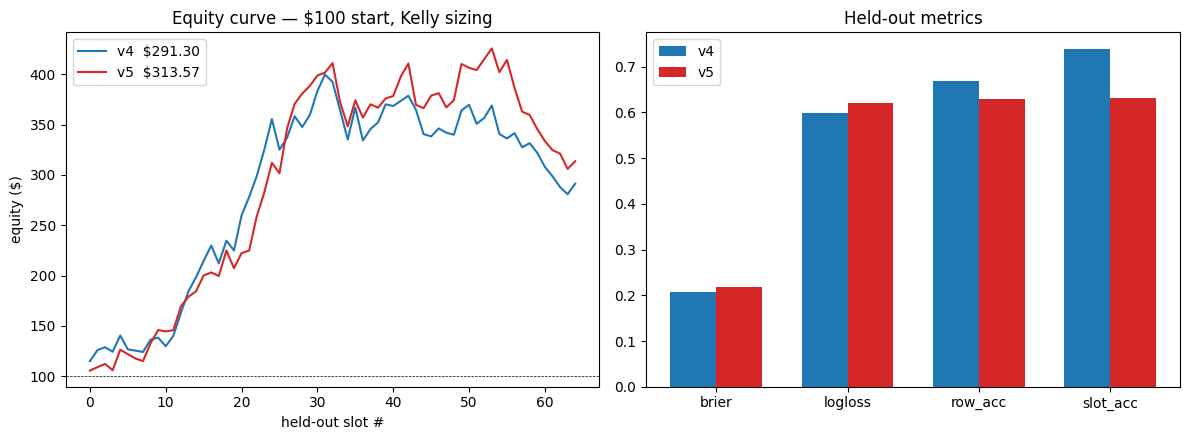

Saved plot → c:\Users\seohj\Desktop\stuffs\side_projects\polymarket\data/v4_vs_v5_backtest.png


In [12]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.plot(np.arange(len(bt4)), bt4["equity"].values, label=f"v4  ${f4:.2f}", color="#1f77b4")
ax.plot(np.arange(len(bt5)), bt5["equity"].values, label=f"v5  ${f5:.2f}", color="#d62728")
ax.axhline(100, color="k", lw=0.5, ls="--")
ax.set_xlabel("held-out slot #"); ax.set_ylabel("equity ($)")
ax.set_title("Equity curve — $100 start, Kelly sizing")
ax.legend(loc="best")

ax = axes[1]
labels_ = ["brier", "logloss", "row_acc", "slot_acc"]
x = np.arange(len(labels_))
w = 0.35
ax.bar(x - w / 2, [metrics["v4"][k] for k in labels_], w, label="v4", color="#1f77b4")
ax.bar(x + w / 2, [metrics["v5"][k] for k in labels_], w, label="v5", color="#d62728")
ax.set_xticks(x); ax.set_xticklabels(labels_)
ax.set_title("Held-out metrics")
ax.legend()

plt.tight_layout()
out_png = os.path.join(REPO_ROOT, "data/v4_vs_v5_backtest.png")
plt.savefig(out_png, dpi=120)
plt.show()
print(f"Saved plot → {out_png}")

## 13. Persist v5 model

In [13]:
with open(os.path.join(v5_dir, "logreg_model.pkl"), "wb") as f:
    pickle.dump(model5, f)
with open(os.path.join(v5_dir, "logreg_scaler.pkl"), "wb") as f:
    pickle.dump(scaler5, f)
with open(os.path.join(v5_dir, "logreg_calibrator.pkl"), "wb") as f:
    pickle.dump(cal5, f)

meta5 = {
    "model_version": "logreg_v5",
    "features": V5_FEATURES,
    "n_train_rows": int(len(X_tr)),
    "n_valid_rows": int(len(X_va)),
    "n_train_slots": int(len(train_slots)),
    "n_valid_slots": int(len(valid_slots)),
    "valid_brier": metrics["v5"]["brier"],
    "valid_logloss": metrics["v5"]["logloss"],
    "valid_row_accuracy": metrics["v5"]["row_acc"],
    "slot_accuracy": metrics["v5"]["slot_acc"],
    "coef": model5.coef_[0].tolist(),
    "intercept": float(model5.intercept_[0]),
    "calibrated": True,
    "backtest": {
        "starting_equity": 100.0,
        "edge_threshold": 0.02,
        "kelly_mult": 0.15,
        "max_frac": 0.10,
        "v4": {"final_equity": f4, "n_trades": n4, "win_rate": wr4},
        "v5": {"final_equity": f5, "n_trades": n5, "win_rate": wr5},
    },
}
with open(os.path.join(v5_dir, "logreg_meta.json"), "w") as f:
    json.dump(meta5, f, indent=2)
df.to_csv(os.path.join(v5_dir, "training_data.csv"), index=False)
print(f"Saved v5 → {v5_dir}/")

Saved v5 → c:\Users\seohj\Desktop\stuffs\side_projects\polymarket\models/logreg_v5/
